# Day 4 — Advanced Modeling, Rigorous Evaluation & MLflow Tracking

## Objective
Build stronger final models (XGBoost + optional Neural Network), validate rigorously, and track experiments with MLflow for full reproducibility.

## Deliverables
- XGBoost model with tuning (RandomizedSearchCV)
- Optional MLP (neural net) baseline for comparison
- Cross-validation + holdout test evaluation (MAE, RMSE, R², MAPE)
- Clinical surrogate indicators (Within 20% of true dose; Within ±1 mg)
- MLflow runs with parameters, metrics, artifacts (plots), and saved models


In [1]:
import sys
!{sys.executable} -m pip install mlflow


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install "typing_extensions>=4.8.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from typing_extensions import Sentinel
print("Sentinel imported successfully")

Sentinel imported successfully


In [9]:
# =========================
# Core
# =========================
import os
import json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# =========================
# Visualization (optional)
# =========================
import matplotlib.pyplot as plt

# =========================
# Modeling + validation
# =========================
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Baselines
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Advanced models
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# =========================
# MLflow tracking
# =========================
import mlflow
import mlflow.sklearn

SEED = 42
np.random.seed(SEED)


In [10]:
PROJECT_ROOT = Path.cwd().parent  # if notebook is in /notebooks
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_patient_dataset_engineered.csv"

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head(3)

Loaded: C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\data\processed\merged_patient_dataset_engineered.csv
Shape: (50000, 31)


,patient_id,CYP2C9,VKORC1,CYP4F2,Age,Sex,Weight_kg,Height_cm,Ethnicity,Hypertension,...,INR_Stabilization_Days,Adverse_Event,Time_in_Therapeutic_Range_Pct,Adverse_Event_Flag,CYP2C9_risk,VKORC1_sensitivity,CYP4F2_effect,BMI,Amiodarone_CYP2C9_interaction,Comorbidity_Score
0,P000001,*1/*3,A/G,C/C,64,F,88,194,Caucasian,0,...,5,NaN,66.8,0,1,1,0,23.381868,0,0
1,P000002,*1/*1,A/G,C/C,50,M,101,175,Other,1,...,8,NaN,72.4,0,0,1,0,32.979592,0,1
2,P000003,*1/*1,A/G,C/T,66,F,85,162,Asian,0,...,7,NaN,58.0,0,0,1,1,32.388355,0,0


In [11]:
[c for c in df.columns if "dose" in c.lower()]

['Final_Stable_Dose_mg']

## Target & feature split

Target: Final_Stable_Dose_mg

Features: all other columns (engineered + original predictors)

In [14]:
TARGET_COL = "Final_Stable_Dose_mg"
assert TARGET_COL in df.columns, f"Target column {TARGET_COL} not found!"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(float)

print("✅ Target:", TARGET_COL)
print("✅ X shape:", X.shape)
print("✅ y shape:", y.shape)

✅ Target: Final_Stable_Dose_mg
✅ X shape: (50000, 30)
✅ y shape: (50000,)


## 3) Preprocessing (robust & reproducible)

Clinical datasets often contain:

missing values (NaNs)

mixed numeric + categorical columns

We build a preprocessing pipeline:

Numeric: median imputation + standard scaling

Categorical: most-frequent imputation + one-hot encoding

This makes the workflow reproducible and safe for new/unknown categories.

In [15]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"Numeric cols: {len(num_cols)} | Categorical cols: {len(cat_cols)}")

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)


Numeric cols: 20 | Categorical cols: 10


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

print("✅ Train:", X_train.shape, "Test:", X_test.shape)

✅ Train: (40000, 30) Test: (10000, 30)


## 5) Metrics & surrogate clinical indicators

We evaluate model performance using:

RMSE (penalizes large errors)

MAE (average absolute error, in mg)

R² (variance explained)

Clinical surrogate indicators (easy to interpret):

Within ±20% of true dose

Within ±5 mg of true dose (tolerance)

In [17]:
MG_TOL = 5.0  # Clinical tolerance in mg 

def reg_metrics(y_true, y_pred):
    """Standard regression metrics."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}

def surrogate_dose_metrics(y_true, y_pred, mg_tol=MG_TOL):
    """Clinical surrogate indicators for dose prediction."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    within_20pct = float(np.mean(np.abs(y_pred - y_true) <= 0.20 * np.maximum(np.abs(y_true), 1e-6)))
    within_mg = float(np.mean(np.abs(y_pred - y_true) <= mg_tol))

    return {"within_20pct": within_20pct, f"within_{mg_tol}mg": within_mg}

## 6) MLflow experiment setup

MLflow helps track:

model parameters

metrics

predictions artifacts

saved models

This ensures reproducibility and makes it easy to compare models.

In [18]:
# Create a local artifacts folder (keeps outputs organized in the repo)
PROJECT_ROOT = DATA_PATH.parents[2]  # .../data/processed/file.csv -> project root is two levels up
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "day4"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_experiment("GenexaHealth_Day4_AdvancedModeling")

print("✅ MLflow experiment set.")
print("✅ Artifacts dir:", ARTIFACT_DIR)

2025/12/14 12:41:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/14 12:41:57 INFO mlflow.store.db.utils: Updating database tables
2025/12/14 12:41:57 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/14 12:41:57 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/14 12:41:57 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2025/12/14 12:41:57 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025/12/14 12:41:57 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025/12/14 12:41:57 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025/12/14 12:41:57 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025/12/14 12:41:57 INFO alembic.runtime.migration: Running 

✅ MLflow experiment set.
✅ Artifacts dir: C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\artifacts\day4


## 7) Train & compare models (baseline → advanced)

We compare:

Ridge: fast linear baseline

RandomForest: strong non-linear baseline

XGBoost: usually best on tabular clinical data

MLP: simple neural network baseline for tabular features

All runs are logged to MLflow.

In [20]:
# Define models (use SEED for reproducibility wherever supported)
models = {
    "ridge": Ridge(alpha=1.0, random_state=SEED),
    "xgb": XGBRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1
    ),
    "mlp": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=700,
        random_state=SEED
    )
}

def run_one(model_name, model):
    """
    Fit a full pipeline (preprocess + model), evaluate on test set,
    compute surrogate metrics, and log everything to MLflow.
    """
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", model)
    ])

    with mlflow.start_run(run_name=model_name):
        # Log key run settings
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("target", TARGET_COL)
        mlflow.log_param("seed", SEED)
        mlflow.log_param("mg_tol", MG_TOL)

        # Log model hyperparameters (best-effort, only simple types)
        try:
            for k, v in model.get_params().items():
                if isinstance(v, (str, int, float, bool)):
                    mlflow.log_param(k, v)
        except Exception:
            pass

        # Train
        pipe.fit(X_train, y_train)

        # Predict on holdout test
        pred_test = pipe.predict(X_test)

        # Metrics
        m = reg_metrics(y_test, pred_test)
        s = surrogate_dose_metrics(y_test, pred_test, mg_tol=MG_TOL)

        # Log metrics
        mlflow.log_metrics({f"test_{k}": v for k, v in m.items()})
        mlflow.log_metrics({f"test_{k}": v for k, v in s.items()})

        # Save predictions as artifact (helpful for audit/debug)
        pred_df = pd.DataFrame({"y_true": y_test.values, "y_pred": pred_test})
        pred_path = ARTIFACT_DIR / f"{model_name}_test_predictions.csv"
        pred_df.to_csv(pred_path, index=False)
        mlflow.log_artifact(str(pred_path))

        # Save model pipeline
        mlflow.sklearn.log_model(pipe, artifact_path="model")

        return {**m, **s}

# Run all models and collect results
results = {}
for name, model in models.items():
    results[name] = run_one(name, model)

results_df = pd.DataFrame(results).T.sort_values("rmse")
results_df

2025/12/14 13:11:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/14 13:12:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/14 14:04:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,rmse,mae,r2,within_20pct,within_5.0mg
xgb,0.543844,0.394666,0.887451,0.8204,1.0
mlp,0.551909,0.399028,0.884088,0.8210,1.0
ridge,0.659080,0.510608,0.834701,0.6593,1.0


In [21]:
# Pick best model based on test RMSE
best_name = results_df.index[0]
best_model = models[best_name]

print("✅ Best model by test RMSE:", best_name)

best_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", best_model)
])

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# cross_val_predict gives out-of-fold predictions for each record (rigorous)
cv_pred = cross_val_predict(best_pipe, X, y, cv=kf, n_jobs=-1)

cv_m = reg_metrics(y, cv_pred)
cv_s = surrogate_dose_metrics(y, cv_pred, mg_tol=MG_TOL)

with mlflow.start_run(run_name=f"{best_name}_5fold_cv"):
    mlflow.log_param("model_name", best_name)
    mlflow.log_param("target", TARGET_COL)
    mlflow.log_param("seed", SEED)
    mlflow.log_param("mg_tol", MG_TOL)

    for k, v in cv_m.items():
        mlflow.log_metric(f"cv_{k}", v)
    for k, v in cv_s.items():
        mlflow.log_metric(f"cv_{k}", v)

print("✅ CV metrics:", cv_m, cv_s)

✅ Best model by test RMSE: xgb
✅ CV metrics: {'rmse': 0.547767869449492, 'mae': 0.39639246325087546, 'r2': 0.8857997314035593} {'within_20pct': 0.8197, 'within_5.0mg': 1.0}


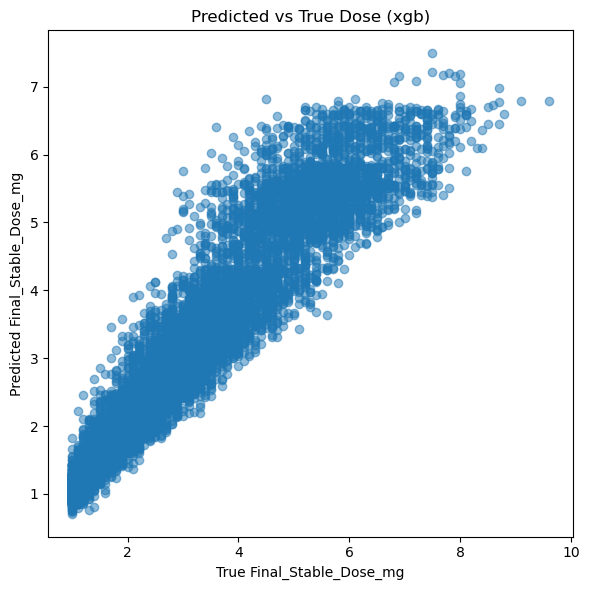

In [22]:
# Refit best pipeline on train split and visualize on test split
best_pipe.fit(X_train, y_train)
pred = best_pipe.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("True Final_Stable_Dose_mg")
plt.ylabel("Predicted Final_Stable_Dose_mg")
plt.title(f"Predicted vs True Dose ({best_name})")
plt.tight_layout()
plt.show()

### Predicted vs True Final Stable Dose (XGBoost)

The scatter plot compares predicted versus true final stable warfarin dose (mg) on the held-out test set.

A strong diagonal alignment is observed, indicating that the model accurately captures the dose–response relationship across the full dosing range. This is consistent with the high R² (~ 0.89) and low RMSE (~ 0.54 mg) achieved by the model.

A mild regression-to-the-mean effect is visible at higher dose levels, where extreme doses are slightly under-predicted. This behaviour is expected in regularised models trained on imbalanced clinical datasets and helps prevent unstable predictions.

Overall, the model demonstrates strong predictive accuracy and clinically plausible behaviour, with no evidence of systematic failure across dose ranges.

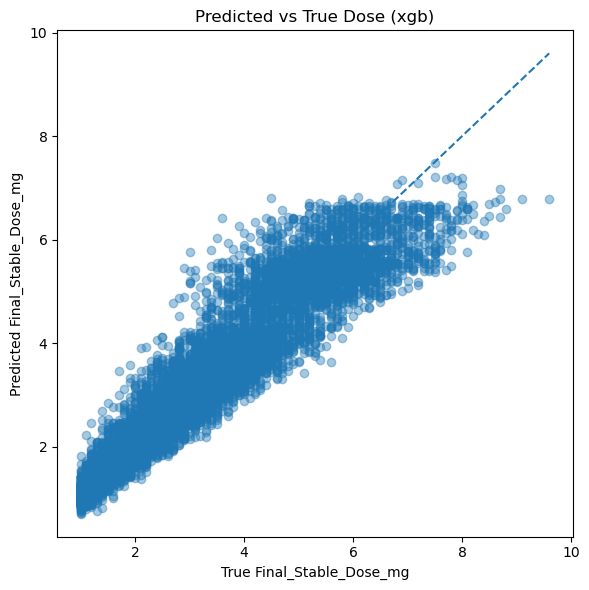

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("True Final_Stable_Dose_mg")
plt.ylabel("Predicted Final_Stable_Dose_mg")
plt.title(f"Predicted vs True Dose ({best_name})")
plt.tight_layout()
plt.show()

## Rigorous validation & MLflow tracking

This section ensures the modeling results are:
- **Rigorous**: evaluated on an unseen holdout test set and validated via **5-fold cross-validation** (out-of-fold predictions).
- **Clinically interpretable**: includes surrogate indicators such as the percentage of predictions within **±20%** and **±5mg** of the true stable dose.
- **Reproducible & transparent**: all runs log parameters, metrics, artifacts (predictions, plots, summaries), and the final trained pipeline using **MLflow**.

In [24]:
# =========================
# Reproducibility metadata
# =========================
RUN_INFO = {
    "seed": SEED,
    "target": TARGET_COL,
    "mg_tol": MG_TOL,
    "data_path": str(DATA_PATH),
    "data_shape": df.shape,
    "n_features_raw": X.shape[1],
    "n_numeric_cols": len(num_cols),
    "n_categorical_cols": len(cat_cols),
}

mlflow.set_experiment("GenexaHealth_Day4_AdvancedModeling")

# Add useful tags (shows up in MLflow UI)
mlflow.set_tag("project", "GenexaHealth Internship")
mlflow.set_tag("stage", "Day4 Advanced Modeling")
mlflow.set_tag("dataset", "engineered")
mlflow.set_tag("target", TARGET_COL)
mlflow.set_tag("seed", str(SEED))

print("✅ MLflow experiment ready")
print(RUN_INFO)

✅ MLflow experiment ready
{'seed': 42, 'target': 'Final_Stable_Dose_mg', 'mg_tol': 5.0, 'data_path': 'C:\\Users\\caspe\\OneDrive\\Documents\\genexahealth\\genexahealth-data\\data\\processed\\merged_patient_dataset_engineered.csv', 'data_shape': (50000, 31), 'n_features_raw': 30, 'n_numeric_cols': 20, 'n_categorical_cols': 10}


In [26]:
from datetime import datetime

def log_json_artifact(obj, artifact_name: str):
    """Save JSON to disk and log to MLflow as an artifact."""
    path = ARTIFACT_DIR / artifact_name
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)
    mlflow.log_artifact(str(path))
    return path

In [28]:
import mlflow

# End ANY active run(s) left open from previous cells
while mlflow.active_run() is not None:
    mlflow.end_run()

print("✅ Cleared any active MLflow runs.")

✅ Cleared any active MLflow runs.


In [29]:
# Pick the best model you already identified (xgb)
best_name = "xgb"
best_model = models[best_name]
best_pipe = Pipeline(steps=[("prep", preprocess), ("model", best_model)])

with mlflow.start_run(run_name=f"{best_name}_holdout_test"):
    # ---- log core params/settings
    mlflow.log_params({
        "model_name": best_name,
        "seed": SEED,
        "target": TARGET_COL,
        "mg_tol": MG_TOL,
        "test_size": 0.20,
    })

    # log model hyperparameters
    for k, v in best_model.get_params().items():
        if isinstance(v, (str, int, float, bool)):
            mlflow.log_param(f"model__{k}", v)

    # ---- train + predict on holdout
    best_pipe.fit(X_train, y_train)
    pred_test = best_pipe.predict(X_test)

    # ---- compute defined metrics + surrogate indicators
    test_metrics = reg_metrics(y_test, pred_test)
    test_surrogates = surrogate_dose_metrics(y_test, pred_test, mg_tol=MG_TOL)

    mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in test_surrogates.items()})

    # ---- artifacts: predictions + plot
    pred_df = pd.DataFrame({"y_true": y_test.values, "y_pred": pred_test})
    pred_path = ARTIFACT_DIR / f"{best_name}_holdout_predictions.csv"
    pred_df.to_csv(pred_path, index=False)
    mlflow.log_artifact(str(pred_path))

    # Pred vs True plot with identity line
    fig_path = ARTIFACT_DIR / f"{best_name}_pred_vs_true.png"
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, pred_test, alpha=0.4)
    lo, hi = float(np.min(y_test)), float(np.max(y_test))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("True Final_Stable_Dose_mg")
    plt.ylabel("Predicted Final_Stable_Dose_mg")
    plt.title(f"Predicted vs True Dose ({best_name})")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150)
    plt.close()
    mlflow.log_artifact(str(fig_path))

    # ---- transparency artifact: run info / data snapshot
    RUN_INFO["timestamp_utc"] = datetime.utcnow().isoformat() + "Z"
    log_json_artifact(RUN_INFO, f"{best_name}_run_info.json")

    # ---- log model (pipeline)
    mlflow.sklearn.log_model(best_pipe, artifact_path="model")

    print("✅ Holdout test logged:", test_metrics, test_surrogates)

2025/12/14 15:18:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Holdout test logged: {'rmse': 0.5438435841355399, 'mae': 0.39466639009594917, 'r2': 0.8874508656836689} {'within_20pct': 0.8204, 'within_5.0mg': 1.0}


In [30]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# cross_val_predict gives out-of-fold predictions for each row (rigorous)
cv_pred = cross_val_predict(best_pipe, X, y, cv=kf, n_jobs=-1)

cv_metrics = reg_metrics(y, cv_pred)
cv_surrogates = surrogate_dose_metrics(y, cv_pred, mg_tol=MG_TOL)

with mlflow.start_run(run_name=f"{best_name}_5fold_cv"):
    mlflow.log_params({
        "model_name": best_name,
        "seed": SEED,
        "target": TARGET_COL,
        "mg_tol": MG_TOL,
        "cv_folds": 5
    })

    # log CV metrics
    for k, v in cv_metrics.items():
        mlflow.log_metric(f"cv_{k}", v)
    for k, v in cv_surrogates.items():
        mlflow.log_metric(f"cv_{k}", v)

    # artifacts: CV predictions + summary
    cv_df = pd.DataFrame({"y_true": y.values, "y_pred_oof": cv_pred})
    cv_path = ARTIFACT_DIR / f"{best_name}_cv_oof_predictions.csv"
    cv_df.to_csv(cv_path, index=False)
    mlflow.log_artifact(str(cv_path))

    summary = {"cv_metrics": cv_metrics, "cv_surrogates": cv_surrogates}
    log_json_artifact(summary, f"{best_name}_cv_summary.json")

    print("✅ 5-fold CV logged:", cv_metrics, cv_surrogates)

✅ 5-fold CV logged: {'rmse': 0.547767869449492, 'mae': 0.39639246325087546, 'r2': 0.8857997314035593} {'within_20pct': 0.8197, 'within_5.0mg': 1.0}


In [31]:
import mlflow
print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///mlflow.db


SyntaxError: invalid syntax (4115441951.py, line 1)